# Part 1: Exercise 1:

In [69]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from scipy.spatial.distance import pdist
from scipy.stats import pearsonr, spearmanr
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader
import glob
from pathlib import Path
from matplotlib.lines import Line2D
from core import (
    MODEL_CLASSES,
    SantoroDataset,
    extract_activations,
    load_yamnet_activations,
)

In [5]:
# load dataset and make RDM
dataset = SantoroDataset()
brain_data = dataset.brain_responses

dl = DataLoader(dataset, batch_size=32, shuffle=False)

brain_rdm_vec = pdist(brain_data, metric="correlation")

def compute_rdm(data):
    flat = data.reshape(data.shape[0], -1)
    return pdist(flat, metric="correlation")


In [6]:
#  load model activations and make RDMs
activations = {}
results = []
model_names = ["waveform", "uninspired", "inspired"]
directories = [Path("models"), Path("assignment/models")]
for model_name in model_names:
    print(f"\nEvaluating architecture: {model_name}")

    # untrained models
    untrained_model = MODEL_CLASSES[model_name](num_classes=50)
    untrained_model.eval()
    untrained_acts = extract_activations(dl, untrained_model)
    activations[f"{model_name}_Untrained"] = untrained_acts

    for layer_idx, (layer_name, acts) in enumerate(untrained_acts.items()):
        m_vec = compute_rdm(acts)
        rho, p_val = spearmanr(m_vec, brain_rdm_vec)
        results.append(
            {
                "Model": model_name,
                "Condition": "Untrained",
                "Run": "untrained",
                "Layer_Idx": layer_idx,
                "Layer_Name": layer_name,
                "Spearman_r": rho,
                "p_val": p_val,
            }
        )

    # trained models
    ckpt_files = []
    for d in directories:
        ckpt_files.extend(sorted(glob.glob(str(d / f"{model_name}*run*.pt"))))

    if not ckpt_files:
        print(f"  Warning: No .pt files found for {model_name} in {directories}. Skipping trained model evaluation.")
        continue

    print(f"  Found {len(ckpt_files)} checkpoints for {model_name}")

    for ckpt_path in ckpt_files:
        run_name = Path(ckpt_path).stem.split("_")[-2]  # e.g., 'run0'
        model = MODEL_CLASSES[model_name](num_classes=50)

        checkpoint = torch.load(
            ckpt_path, map_location="cpu", weights_only=False
        )
        if isinstance(checkpoint, dict):
            if "model_state_dict" in checkpoint:
                state_dict = checkpoint["model_state_dict"]
            elif "state_dict" in checkpoint:
                state_dict = checkpoint["state_dict"]
            else:
                state_dict = checkpoint
        else:
            state_dict = checkpoint

        model.load_state_dict(state_dict)
        model.eval()

        layer_acts = extract_activations(dl, model)
        # Store run0 activations for t-SNE visualization
        if run_name == "run0":
            activations[f"{model_name}_Trained"] = layer_acts

        for layer_idx, (layer_name, acts) in enumerate(layer_acts.items()):
            m_vec = compute_rdm(acts)
            rho, p_val = spearmanr(m_vec, brain_rdm_vec)
            results.append(
                {
                    "Model": model_name,
                    "Condition": "Trained",
                    "Run": run_name,
                    "Layer_Idx": layer_idx,
                    "Layer_Name": layer_name,
                    "Spearman_r": rho,
                    "p_val": p_val,
                }
            )


Evaluating architecture: waveform
  Found 5 checkpoints for waveform

Evaluating architecture: uninspired
  Found 5 checkpoints for uninspired

Evaluating architecture: inspired
  Found 5 checkpoints for inspired


In [7]:
# load yamnet activations and make RDM
yamnet_activations = load_yamnet_activations()
activations["yamnet"] = yamnet_activations

for layer_idx, (layer_name, acts) in enumerate(yamnet_activations.items()):
    m_vec = compute_rdm(acts)
    rho, p_val = spearmanr(m_vec, brain_rdm_vec)
    results.append(
        {
            "Model": "yamnet",
            "Condition": "Pretrained",
            "Run": "pretrained",
            "Layer_Idx": layer_idx,
            "Layer_Name": layer_name,
            "Spearman_r": rho,
            "p_val": p_val,
        }
    )

df_rsa = pd.DataFrame(results)
print("\nRSA Summary:")
print(
    df_rsa.groupby(["Model", "Condition"])["Spearman_r"].max().reset_index()
)


RSA Summary:
        Model   Condition  Spearman_r
0    inspired     Trained    0.067118
1    inspired   Untrained    0.086595
2  uninspired     Trained    0.037480
3  uninspired   Untrained    0.047634
4    waveform     Trained    0.006758
5    waveform   Untrained   -0.010082
6      yamnet  Pretrained    0.098000


I loaded the santoro dataset and computed the RDM for the brain responses. Then, I loaded the activations from different models (both untrained and trained) and computed their RDMs for each layer (5 layers each). I also loaded the activations from the pretrained yamnet model and computed its RDM across layers. Finally, I compared the model RDMs with the brain RDM using Spearman correlation and summarized the results in a DataFrame. The spearman correlation values indicate how well each model's representations align with the brain's representations for the same stimuli.

# Part 1: Exercise 2:

## the effect of training on brain alignment, comparing the untrained to the trained models

### Code set up for analysis

In [24]:
# df_rsa[["Model", "Condition", "Layer_Idx", "Layer_Name", "Spearman_r"]].sort_values(
#    ["Model", "Condition", "Layer_Idx"]
#)

In [36]:
trained_mean = (
    df_rsa[df_rsa["Condition"] == "Trained"]
    .groupby(["Model", "Layer_Idx", "Layer_Name"])["Spearman_r"]
    .agg(["mean", "std", "count"])
    .reset_index()
)


untrained = (
    df_rsa[df_rsa["Condition"] == "Untrained"]
    [["Model", "Layer_Idx", "Layer_Name", "Spearman_r"]]
)

# trained_mean


In [37]:
trained_for_comparison = trained_mean.rename(
    columns={"mean": "RSA_Trained"}
)

untrained_for_comparison = untrained.rename(
    columns={"Spearman_r": "RSA_Untrained"}
)

#merging the trained and untrained results after renaming the mean and spearman
comparison = trained_for_comparison.merge(
    untrained_for_comparison,
    on=["Model", "Layer_Idx", "Layer_Name"]
)

#calculating the effects of training (RSA Change)
comparison["RSA_Change"] = (
    comparison["RSA_Trained"] - comparison["RSA_Untrained"]
)

comparison

,Model,Layer_Idx,Layer_Name,RSA_Trained,std,count,RSA_Untrained,RSA_Change
0,inspired,0,conv_layers.0,-0.060679,0.016732,5,-0.053012,-0.007667
1,inspired,1,conv_layers.1,-0.004857,0.020940,5,-0.083034,0.078177
2,inspired,2,conv_layers.2,0.044749,0.019023,5,-0.015196,0.059945
3,inspired,3,rnn,0.045853,0.011478,5,0.086595,-0.040743
4,inspired,4,classifier,0.054729,0.010486,5,0.060227,-0.005498
5,uninspired,0,conv_layers.0,-0.050842,0.005383,5,-0.054272,0.003430
6,uninspired,1,conv_layers.1,-0.016277,0.007703,5,-0.048027,0.031749
7,uninspired,2,conv_layers.2,0.012512,0.011101,5,0.018111,-0.005599
8,uninspired,3,fc_layers.0,0.026524,0.008178,5,0.047634,-0.021110
9,uninspired,4,fc_layers.1,0.032986,0.005446,5,0.047265,-0.014279


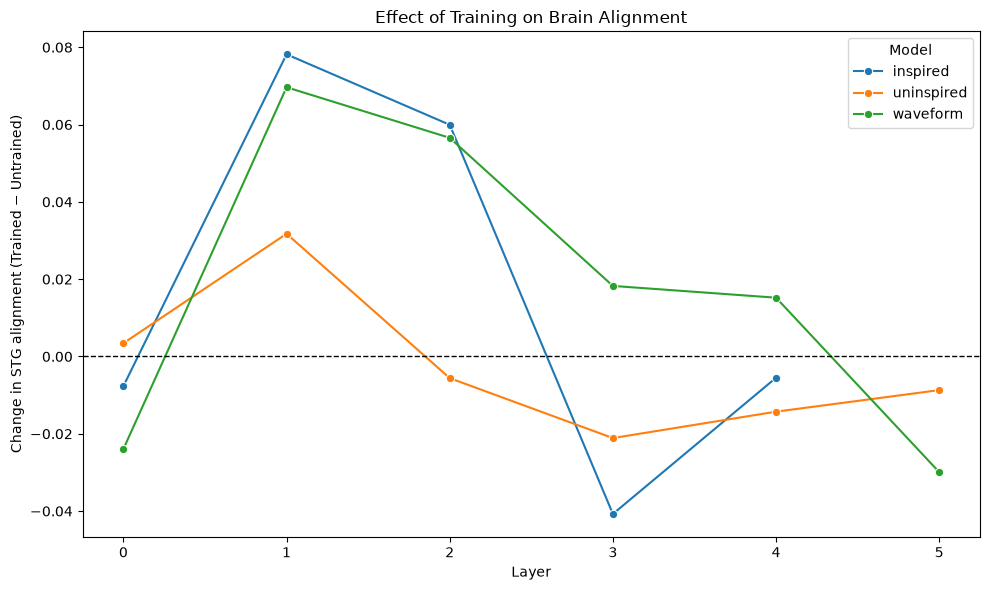

In [50]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=comparison,
    x="Layer_Idx",
    y="RSA_Change",
    hue="Model",
    marker="o"
)

plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.xlabel("Layer")
plt.ylabel("Change in STG alignment (Trained − Untrained)")
plt.title("Effect of Training on Brain Alignment")

plt.tight_layout()
plt.show()

### Actual Analysis now:

Given the three models: inspired,uninspired and waveform; we compared trained and untrained models by finding the change in their RSA scores (mean of trained - spearman correlation of untrained) as our metric for allignment and compred them at different layers.
Positive value meant the training model is more similar to the STG while negative meant it's less similar.
As we can see the graph above, at different layers brain allignment changed differently (it didnt stay at zero) and this varied for each of the 3 models:

    For inspired model RSA change remains positive well up to layer 3 (although the change is relatively low), after that it remains in negative (still the change isn't that significant).
    
    For uninspired model RSA change remains in positive till layer 2 and till layer 4 for waveform (again, the change is relatively low), after that they remain negative with relatively low change in RSA.

    Additionally, all 3 models increase in change in layer 1 while decreasing afterware with inspired having the sharpest decline between layer 2 and 3. While increase is limted, inspired and unspired do see an increase after layer 3.

We can conlude (based on the low value of change) that training affects the allignment modestly and is layer dependent rather than consistently improving or making the allignment worse.

## The effect of architectural choices on brain alignment


### The code

In [47]:
architecture_data = df_rsa[
    (df_rsa["Condition"] == "Trained") &
    (df_rsa["Model"].isin(["inspired", "uninspired", "waveform"]))
]

architecture_mean = (
    architecture_data
    .groupby(["Model", "Layer_Idx", "Layer_Name"])["Spearman_r"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

#architecture_mean

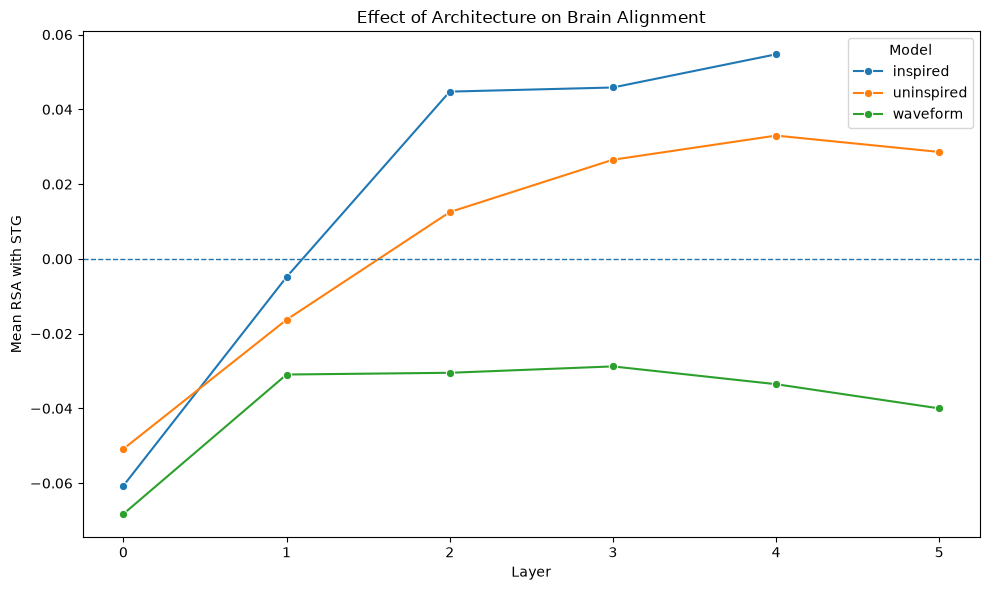

In [48]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=architecture_mean,
    x="Layer_Idx",
    y="mean",
    hue="Model",
    marker="o"
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Layer")
plt.ylabel("Mean RSA with STG")
plt.title("Effect of Architecture on Brain Alignment")

plt.tight_layout()
plt.show()

### The analysis

To compare the architectures (inspired,uninspired, and waveform) and how they behave against brain allignment we compared their trained RSA scores against different layers.

While all 3 remained in the negative area before layer 1, both inspired and uninspired models rose to the positive RSA area after layer 1 (with waveform remaining in negative area).

The inspired model showed the highest brain allignment while unspired showed less with waveform remainining negatively alligned. Inspired model also shows greater increase with uninspired slowing down its increase and eventually dipping slightly and waveform almost flatting before decreasing in the deeper layers again.

These results suggest different architectures are associated with different varities of allignment per layer, inspired allignment shows a relatively greater allignment accross layers.

## How well layers at different depths of the models align with brain data of the STG

Relying on the graphs produced for the previous parts (effect of architecture on brain allignment and effect of training on brain allignment), we can see that the depth of layers suugest an association with RSA scores of the 3 different architectures in both trained and untrained scenarios. 

We can see (from the effect of architecture on brain allignment graph) that uninspired and inspired models generally show increasing allignment in deeper layers (with waveform remaining negatively alligned across all 5 layers). This suggests that both inspired and uninspired models show a more similar representation  in deeper layers to the structure in STG.

# Part 1: Exercise 3:

## Use tSNE or something similar (if you are part of the t-SNE hater club) to visualize how the layers of the models distinguish categories and compare the results to the brain data. extract_activations gives you the per-layer activations to feed into sklearn.manifold.TSNE.


In [55]:
#for model_condition, layers in activations.items():
#    print(f"\n{model_condition}")
#    
#    for layer_name, acts in layers.items():
#        print(layer_name, np.shape(acts))

In [72]:
acts = activations["inspired_Trained"]["conv_layers.0"]
acts = acts.detach().cpu().numpy()
acts = acts.reshape(acts.shape[0], -1)

#print(acts.shape)

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

embedding = tsne.fit_transform(acts)

#print(embedding.shape)

### Note: The legend is produced separately 

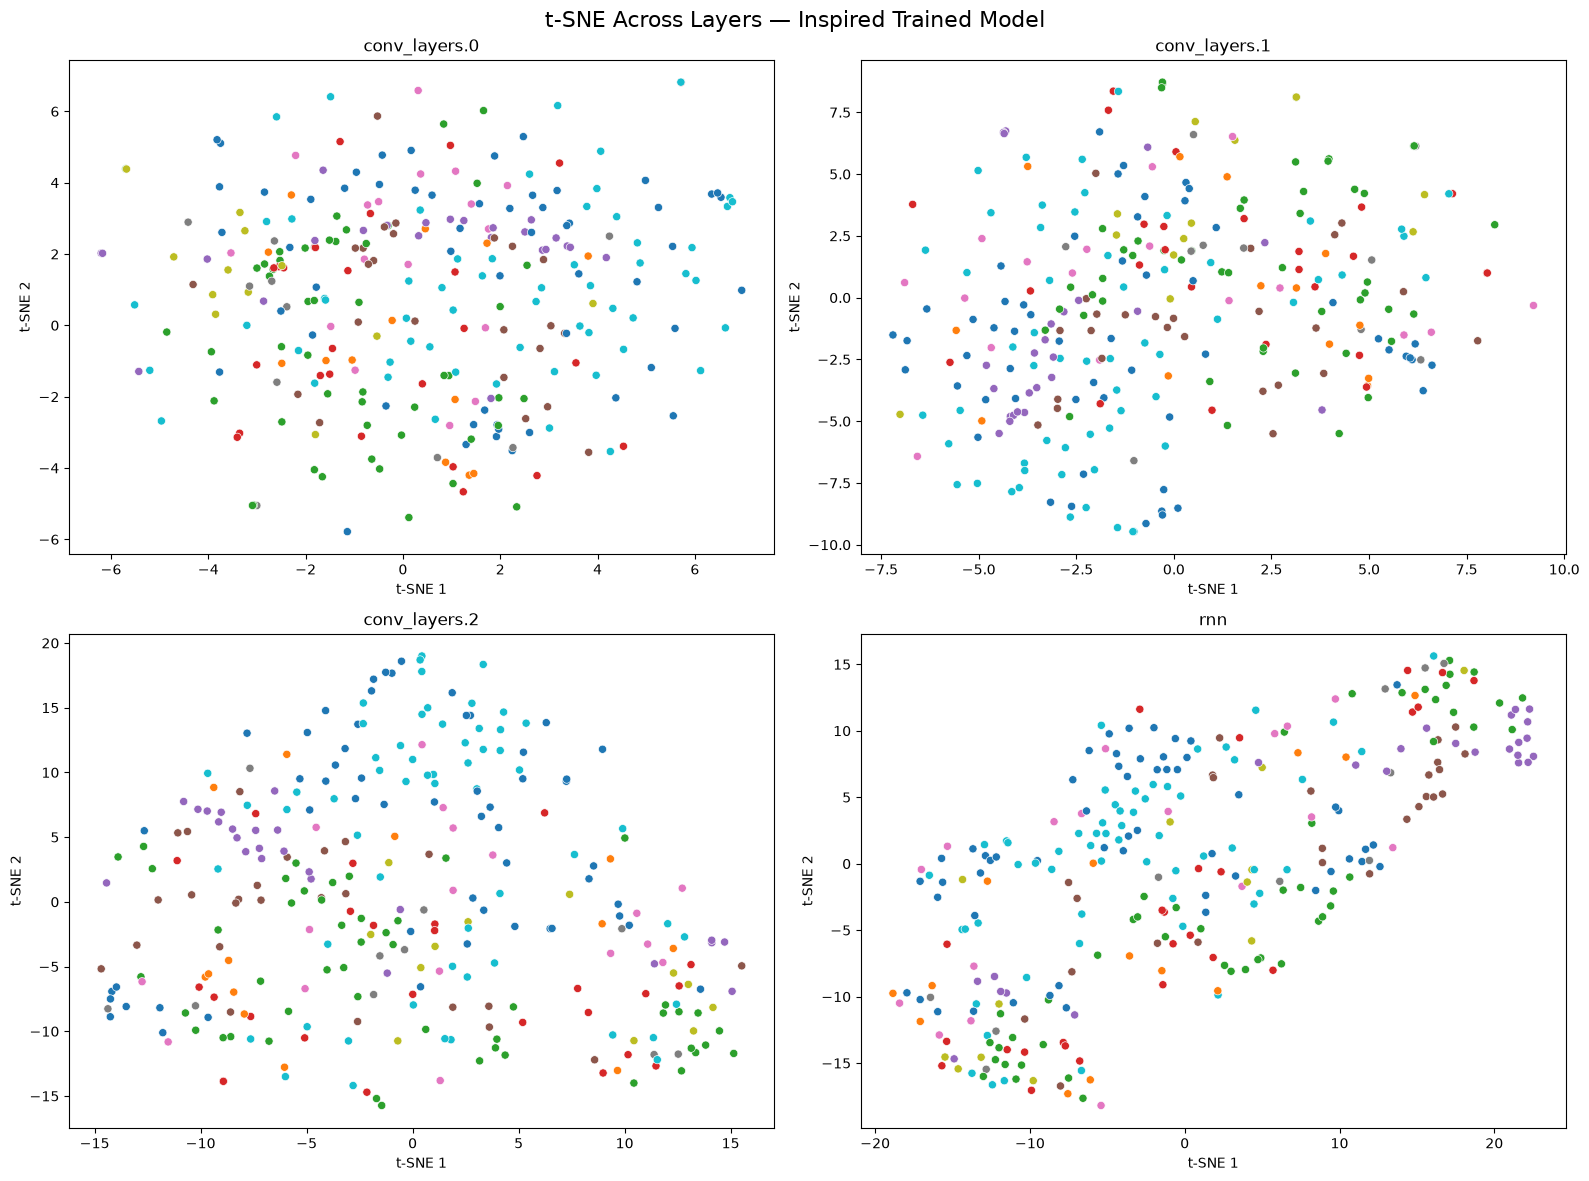

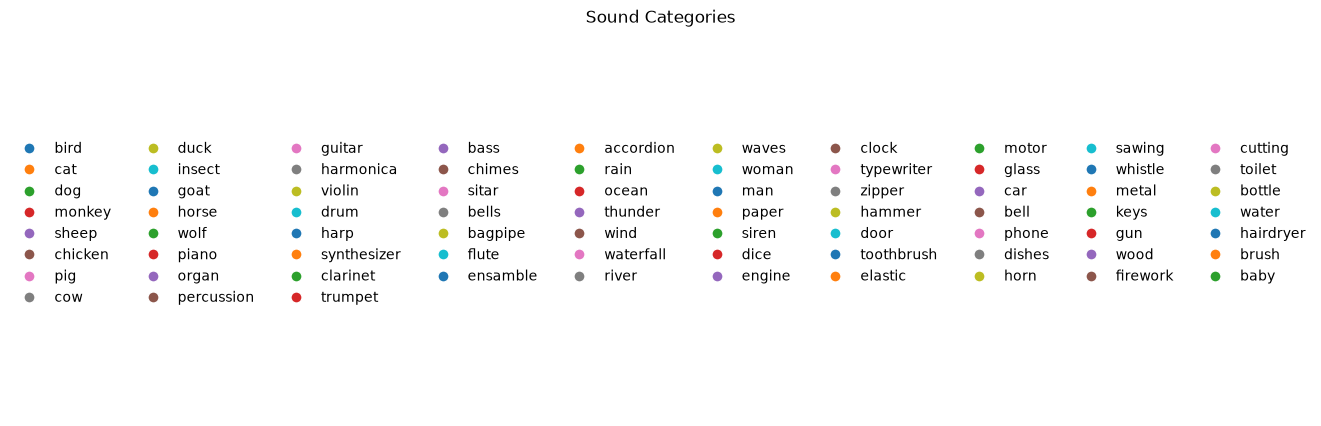

In [71]:
labels = [dl.dataset[i][-1] for i in range(len(dl.dataset))]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

layers_to_plot = [
    "conv_layers.0",
    "conv_layers.1",
    "conv_layers.2",
    "rnn"
]

for ax, layer_name in zip(axes.flat, layers_to_plot):

    acts = activations["inspired_Trained"][layer_name]
    acts = acts.detach().cpu().numpy()
    acts = acts.reshape(acts.shape[0], -1)

    tsne = TSNE(
        n_components=2,
        random_state=42,
        perplexity=30
    )

    embedding = tsne.fit_transform(acts)

    #plot
    sns.scatterplot(
        x=embedding[:, 0],
        y=embedding[:, 1],
        hue=labels,
        palette="tab10",
        s=35,
        ax=ax,
        legend=False
    )

    ax.set_title(layer_name)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

plt.suptitle(
    "t-SNE Across Layers — Inspired Trained Model",
    fontsize=16
)

plt.tight_layout()
plt.show()
#Generating the legend separately to avoid a graphical glitch
unique_labels = list(dict.fromkeys(labels))

palette = sns.color_palette("tab10", n_colors=len(unique_labels))

legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor=palette[i],
        markersize=8,
        label=label
    )
    for i, label in enumerate(unique_labels)
]

plt.figure(figsize=(16, 5))

plt.legend(
    handles=legend_handles,
    labels=unique_labels,
    loc="center",
    ncol=10,
    frameon=False
)

plt.axis("off")
plt.title("Sound Categories")

plt.show()

The t-SNE visualization if the trained model shows 288 sound stimuli on a 2D graph. Each point is a stimulus and the color is a category. In the earlier layers there is a relatively large amount of overlap, with deeper layers showing less overlap (overlap still remains but becomes less as layers get deeper) and showing more distinct groups of stimuli. We can see that as layers get deeper, more structured distribution of the representations/organization becomes apparent with several groups becoming more spatially apparent compared to former layers.